# NVDA — The One-Time 2026 Evaluation: Does a Loosened Gate Help?

> **Part 6 of 6.** Builds on [`05_discovery_loop.ipynb`](05_discovery_loop.ipynb).

The strict gate in notebook 5 graduated nothing. This notebook asks what a **looser**
standard buys, and answers it on the one window none of the work had been scored on:
**2026**. It was used once, under a plan written and committed before any 2026 score
([`experiments/exploratory/preregistration.md`](experiments/exploratory/preregistration.md)).

> **Disclosure.** The 2026 price data was not blind: the 2026 shock days had been printed
> while checking the cache, and two of them follow earnings. Read the earnings result with
> that in mind.

> Reads committed results only. Run from `implementations/`; no LLM calls.

In [1]:
import warnings


warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yaml
from ai_stocks_forecasting.charts import load_shock_frame, shock_leaderboard, shock_separation
from ai_stocks_forecasting.data import build_nvda_service
from ai_stocks_forecasting.exploratory import EXPLORATORY_DIR, load_patterns


pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 80)

---

## 1. Gate A, the loosened gate

| | Strict gate | Gate A |
|---|---|---|
| 2020–24 lift | ≥ 2.0 | ≥ 1.5 |
| 2020–24 p-value | < 0.05 | < 0.10 |
| 2020–24 lift interval above 1 | required | dropped |
| 2025 lift | ≥ 1.5 | ≥ 1.0 ("not contradicted") |
| 2025 p-value | < 0.10 | dropped |
| A pattern with no effect passes, per candidate | 0.1–0.2% | 3–5% |

All fifteen candidates were re-scored. The three news candidates whose 2025 lift was at
least 1.0 got their 2020–24 labels first ($12.17).

In [2]:
gate = yaml.safe_load((EXPLORATORY_DIR / "gate_a_results.yaml").read_text())
table = pd.DataFrame(gate["candidates"])
print(f"{gate['graduated']} of {gate['candidates_tested']} candidates graduated under Gate A")
table[["pattern_id", "experiment", "direction", "train_lift", "train_p", "train_matches", "holdout_lift", "gate_a"]]

1 of 15 candidates graduated under Gate A


,pattern_id,experiment,direction,train_lift,train_p,train_matches,holdout_lift,gate_a
0,P-1,exp01_earnings,either,3.165,0.0297,11.0,3.581,True
1,P-2,exp01_earnings,up,2.508,0.0715,11.0,0.000,False
2,P-3,exp01_earnings,either,1.151,0.2097,87.0,1.909,False
3,exp02_export_controls_q1,exp02_export_controls,either,0.695,0.8152,5.0,1.000,False
4,exp02_export_controls_q2,exp02_export_controls,either,NaN,NaN,NaN,NaN,False
5,exp03_hyperscaler_capex_q1,exp03_hyperscaler_capex,up,NaN,NaN,NaN,0.000,False
6,exp03_hyperscaler_capex_q2,exp03_hyperscaler_capex,down,0.000,1.0000,1.0,25.556,False
7,exp04_competitor_launches_q1,exp04_competitor_launches,down,NaN,NaN,NaN,0.000,False
8,exp04_competitor_launches_q2,exp04_competitor_launches,down,NaN,NaN,NaN,0.000,False
9,exp05_nvda_corporate_q1,exp05_nvda_corporate,up,1.268,0.2941,31.0,1.267,False


In [3]:
pd.DataFrame([p.__dict__ for p in load_patterns()]).round(3)

,pattern_id,cue,rule,direction,train_precision,train_lift,holdout_lift
0,X-1,NVDA reports quarterly results after the close,earnings_after_close,either,0.381,3.165,3.581


Only **earnings** passes. Hyperscaler capex caution, the strongest news lead in 2025,
matched a single 2020–24 window and it was not a shock.

---

## 2. The 2026 evaluation

An after-close origin on every 2026 session (182 origins, 7 shocks), four forecasters:

1. **Climatology**: the historical shock rate.
2. **Climatology + patterns** (no LLM): the pattern's 2020–24 shock rate (38%) on a day it
   fires, climatology otherwise.
3. **Agent**: the after-close news-grounded agent.
4. **Agent + patterns**: the same agent, told the pattern's evidence and whether it fires.

In [4]:
frame = load_shock_frame(build_nvda_service(), ("nvda_shock_oot_2026",))
shock_leaderboard(frame)[
    ["n", "shocks", "brier", "brier_skill", "diff_lo", "diff_hi", "mean_p_shock", "mean_p_calm", "separation"]
]

n  shocks  brier  brier_skill  diff_lo  diff_hi  mean_p_shock  mean_p_calm  separation
spec                arm                                                                                                             
nvda_shock_oot_2026 Agent, after close      182       7  0.055       -0.229    0.003    0.017         0.197        0.158       0.039
                    Agent + patterns        182       7  0.044        0.001   -0.009    0.007         0.257        0.143       0.114
                    Climatology + patterns  182       7  0.041        0.078   -0.008    0.001         0.199        0.127       0.072
                    Climatology             182       7  0.045          NaN      NaN      NaN         0.125        0.125       0.000

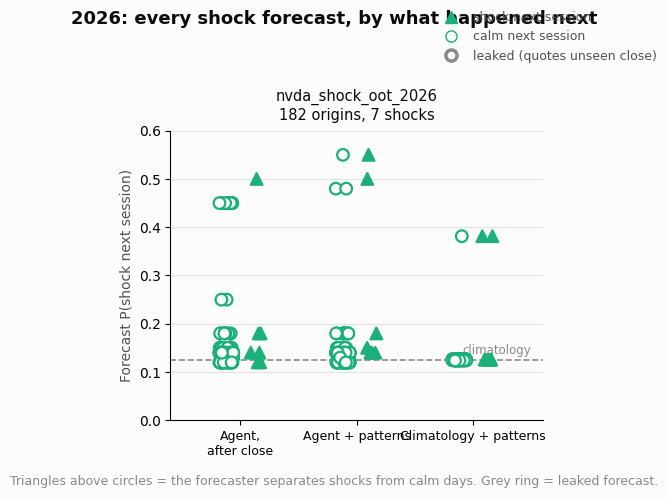

In [5]:
fig, axes = shock_separation(frame, title="2026: every shock forecast, by what happened next")

### The three earnings days

In [6]:
earnings_days = pd.to_datetime(["2026-02-25", "2026-05-20", "2026-08-26"])
frame[frame["as_of"].isin(earnings_days)].pivot(index=["as_of", "outcome"], columns="arm", values="probability").round(
    2
)

,arm,Agent + patterns,"Agent, after close",Climatology,Climatology + patterns
as_of,outcome,,,,
2026-02-25,1,0.55,0.50,0.13,0.38
2026-05-20,0,0.48,0.45,0.13,0.38
2026-08-26,1,0.50,0.14,0.12,0.38


### Agent with patterns against agent alone

In [7]:
wide = frame.pivot(index="as_of", columns="arm", values="brier")
diff = (wide["Agent + patterns"] - wide["Agent, after close"]).to_numpy()
boot = np.random.default_rng(0).choice(diff, size=(2000, len(diff))).mean(axis=1)
low, high = np.quantile(boot, [0.05, 0.95])
print(f"Brier difference {diff.mean():+.4f}, 90% interval {low:+.4f} to {high:+.4f}")

Brier difference -0.0102, 90% interval -0.0171 to -0.0045


---

## 3. Against the pre-registered rule

A forecaster *helps* if its skill against climatology is above zero **and** the 90%
interval on its Brier difference lies entirely below zero.

| Forecaster | Verdict |
|---|---|
| Climatology + patterns | **Does not meet the rule.** Best Brier (0.041, skill +0.078), but the interval reaches +0.001: it changes only three forecasts |
| Agent | **Worse than climatology**, measurably (interval +0.003 to +0.017). It raised P above 0.3 on ten calm days |
| Agent + patterns | **Ties climatology** (skill +0.001) |
| Agent + patterns vs agent | **The patterns help the agent** (interval −0.017 to −0.005). It caught the 2026-08-26 earnings reaction (0.14 → 0.50) and raised P above 0.3 on three calm days instead of ten |

## 4. Takeaways

- **A loosened gate let through one pattern, earnings**, and it behaved in 2026 as its
  training said it would: 2 of 3 earnings reactions were shocks, against a 38% training rate.
- **Patterns made the agent better, not good.** Given the earnings evidence, the agent
  stopped issuing high probabilities on ordinary days. It still only tied climatology.
- **Nothing beat climatology by the pre-registered standard**: 182 days with 7 shocks is
  a small sample, and the pattern fires four times a year.
- **The 2026 window is now used.** Any later claim needs new post-cutoff data, which is the
  case for more tickers (Phase 4).